# 支持向量机：乳腺肿瘤数据分类教学项目

**适合人群：** 已完成 Python 入门，希望通过项目学习支持向量机（SVM）的初学者。

**项目目标：** 根据肿瘤细胞核的测量特征，将样本分类为良性或恶性。

**完成标准：** 能解释为什么 SVM 需要特征缩放，完成基准比较、参数搜索、模型评估、单样本预测和模型保存。

> 本项目仅用于机器学习教学。数据和模型不能用于真实医疗诊断或治疗决策。

## 项目路线

1. 理解 SVM 的任务和关键参数
2. 加载并检查数据
3. 探索类别和特征
4. 隔离测试集
5. 建立多数类基准
6. 比较缩放前后的 SVM
7. 用交叉验证搜索参数
8. 在测试集上进行最终评估
9. 解释、预测并保存模型

## SVM 在做什么？

支持向量机寻找一条能够尽量拉开两类样本距离的分类边界。离边界最近的样本叫作支持向量。

本项目关注三个参数：

- `kernel`：边界形状，常用 `linear` 和 `rbf`。
- `C`：对分类错误的惩罚强度。越大越努力拟合训练数据。
- `gamma`：RBF 核中单个样本的影响范围。过大容易过拟合。

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42
CLASS_NAMES = ["benign", "malignant"]
sns.set_theme(style="whitegrid")

print("pandas 版本：", pd.__version__)
print("scikit-learn 版本：", sklearn.__version__)

pandas 版本： 1.5.3
scikit-learn 版本： 1.2.2


## 1. 加载数据

数据集随 `scikit-learn` 提供，不需要联网下载。原始数据用 0 表示恶性、1 表示良性；本项目重新编码为 **1 表示恶性**，这样召回率直接表示恶性样本被识别出的比例。

In [2]:
dataset = load_breast_cancer(as_frame=True)
X = dataset.data.copy()
y = (dataset.target == 0).astype(int).rename("is_malignant")

df = X.copy()
df["diagnosis"] = y.map({0: "benign", 1: "malignant"})

print(f"样本数：{len(df)}")
print(f"特征数：{X.shape[1]}")
df.head()

样本数：569
特征数：30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## 2. 检查数据

先检查缺失值、重复记录和类别数量。真实项目不能跳过这一步。

In [3]:
quality_check = pd.Series({
    "缺失值总数": int(X.isna().sum().sum()),
    "重复行数量": int(X.duplicated().sum()),
    "良性样本": int((y == 0).sum()),
    "恶性样本": int((y == 1).sum()),
}, name="检查结果")
quality_check.to_frame()

,检查结果
缺失值总数,0
重复行数量,0
良性样本,357
恶性样本,212


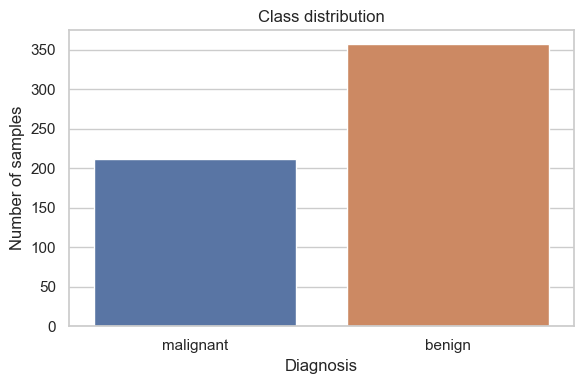

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diagnosis", hue="diagnosis", legend=False)
plt.title("Class distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

良性样本多于恶性样本，因此只看准确率可能产生误导。最终同时报告恶性召回率、精确率和 ROC-AUC。

## 3. 探索部分特征

30 个特征全部画出来会很拥挤。先选择 4 个容易理解的平均值特征，对比两类样本的中位数。

In [5]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean concavity",
]

df.groupby("diagnosis")[selected_features].median().round(2)

,mean radius,mean texture,mean perimeter,mean concavity
diagnosis,,,,
benign,12.20,17.39,78.18,0.04
malignant,17.33,21.46,114.20,0.15


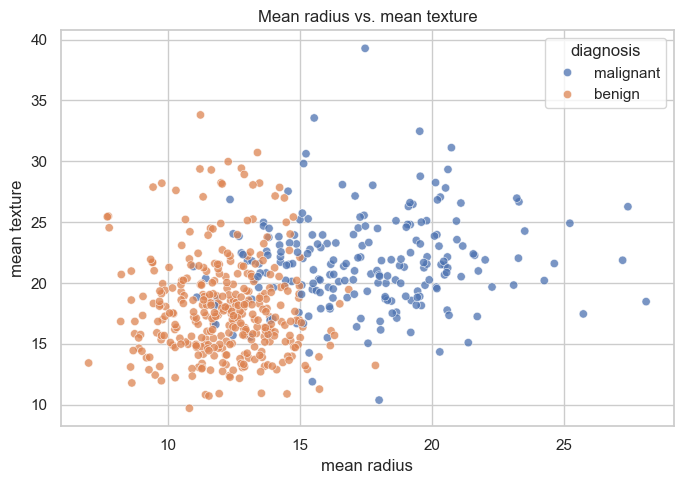

In [6]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="mean radius",
    y="mean texture",
    hue="diagnosis",
    alpha=0.75,
)
plt.title("Mean radius vs. mean texture")
plt.tight_layout()
plt.show()

两类样本有明显趋势，但不能只靠两个特征完全分开。SVM 会同时使用全部 30 个特征。

## 4. 隔离测试集

测试集占 20%，只在模型和参数确定后使用一次。`stratify=y` 保持两类样本比例一致。

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("训练集：", X_train.shape)
print("测试集：", X_test.shape)
print("训练集中恶性比例：", f"{y_train.mean():.1%}")
print("测试集中恶性比例：", f"{y_test.mean():.1%}")

训练集： (455, 30)
测试集： (114, 30)
训练集中恶性比例： 37.4%
测试集中恶性比例： 36.8%


## 5. 建立基准模型

多数类基准总是预测良性。一个有效模型必须明显优于它，尤其要提高恶性召回率。所有比较只使用训练集交叉验证。

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
baseline = DummyClassifier(strategy="most_frequent")

baseline_accuracy = cross_val_score(
    baseline, X_train, y_train, cv=cv, scoring="accuracy"
).mean()
baseline_recall = cross_val_score(
    baseline, X_train, y_train, cv=cv, scoring="recall"
).mean()

print(f"基准准确率：{baseline_accuracy:.2%}")
print(f"基准恶性召回率：{baseline_recall:.2%}")

基准准确率：62.64%
基准恶性召回率：0.00%


## 6. 为什么 SVM 需要特征缩放？

SVM 根据样本之间的距离寻找边界。本数据的面积和紧致度等特征量纲差异很大，数值大的特征会不合理地主导距离。`Pipeline` 确保标准化只从每一折的训练数据中学习，避免数据泄漏。

In [9]:
unscaled_svm = SVC(kernel="rbf", class_weight="balanced")
scaled_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", class_weight="balanced")),
])

unscaled_score = cross_val_score(
    unscaled_svm, X_train, y_train, cv=cv, scoring="roc_auc"
).mean()
scaled_score = cross_val_score(
    scaled_svm, X_train, y_train, cv=cv, scoring="roc_auc"
).mean()

pd.Series({
    "未缩放 SVM": unscaled_score,
    "标准化后 SVM": scaled_score,
}, name="交叉验证 ROC-AUC").to_frame().round(3)

,交叉验证 ROC-AUC
未缩放 SVM,0.969
标准化后 SVM,0.995


## 7. 搜索 SVM 参数

我们比较线性核和 RBF 核，并搜索不同的 `C` 与 `gamma`。搜索只在训练集的 5 折交叉验证中进行，以恶性召回率作为选择最佳模型的首要指标。

In [10]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_STATE,
    )),
])

parameter_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.1, 1, 10],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10, 100],
        "svc__gamma": ["scale", 0.01, 0.001],
    },
]

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=parameter_grid,
    scoring={
        "accuracy": "accuracy",
        "malignant_recall": "recall",
        "roc_auc": "roc_auc",
    },
    refit="malignant_recall",
    cv=cv,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
print("参数搜索完成")

参数搜索完成


In [11]:
search_results = (
    pd.DataFrame(grid_search.cv_results_)
    .sort_values(["rank_test_malignant_recall", "rank_test_roc_auc"])
    [[
        "params",
        "mean_test_accuracy",
        "mean_test_malignant_recall",
        "mean_test_roc_auc",
    ]]
    .head(5)
)
search_results

,params,mean_test_accuracy,mean_test_malignant_recall,mean_test_roc_auc
9,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke...",0.971429,0.964706,0.993292
14,"{'svc__C': 100, 'svc__gamma': 0.001, 'svc__ker...",0.973626,0.958824,0.995872
10,"{'svc__C': 10, 'svc__gamma': 0.01, 'svc__kerne...",0.980220,0.958824,0.995666
13,"{'svc__C': 100, 'svc__gamma': 0.01, 'svc__kern...",0.967033,0.958824,0.993189
12,"{'svc__C': 100, 'svc__gamma': 'scale', 'svc__k...",0.964835,0.958824,0.989267


In [12]:
best_model = grid_search.best_estimator_
print("最佳参数：", grid_search.best_params_)
print(f"最佳交叉验证恶性召回率：{grid_search.best_score_:.2%}")

最佳参数： {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
最佳交叉验证恶性召回率：96.47%


## 8. 测试集最终评估

模型和参数已经确定，现在才使用测试集。此结果用于估计模型面对未见数据时的表现。

In [13]:
y_pred = best_model.predict(X_test)
y_probability = best_model.predict_proba(X_test)[:, 1]

final_metrics = pd.Series({
    "准确率": accuracy_score(y_test, y_pred),
    "恶性精确率": precision_score(y_test, y_pred),
    "恶性召回率": recall_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_probability),
}, name="测试集结果")

display(final_metrics.to_frame().style.format("{:.2%}"))
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

,测试集结果
准确率,97.37%
恶性精确率,100.00%
恶性召回率,92.86%
ROC-AUC,99.27%


              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



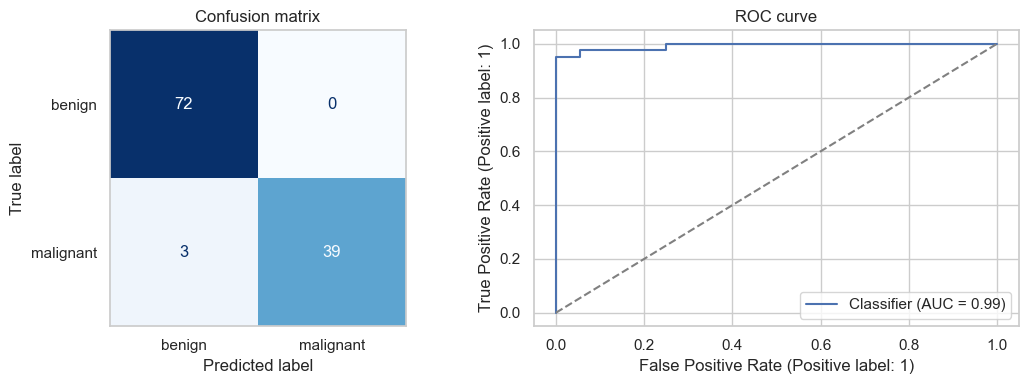

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=CLASS_NAMES,
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Confusion matrix")
axes[0].grid(False)

RocCurveDisplay.from_predictions(y_test, y_probability, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("ROC curve")

plt.tight_layout()
plt.show()

混淆矩阵中，真实恶性但预测为良性的样本是假阴性。教学项目可以观察该数量，但真实医疗系统还需要外部验证、概率校准、临床标准和专业人员审核。

## 9. 使用置换重要性解释模型

RBF SVM 不直接提供容易解释的特征权重。置换重要性会打乱一个特征，观察恶性召回率下降多少。它只能说明模型依赖哪些特征，不能证明医学因果关系。

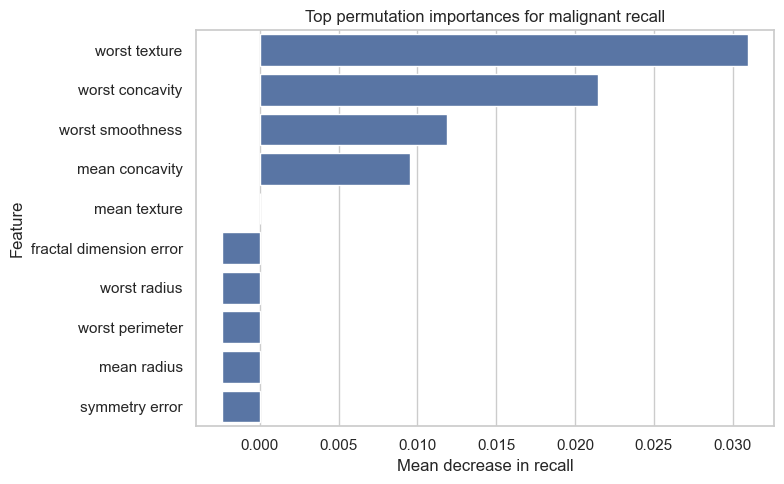

In [15]:
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="recall",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_table = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": importance.importances_mean,
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_table, x="importance", y="feature")
plt.title("Top permutation importances for malignant recall")
plt.xlabel("Mean decrease in recall")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. 预测一个样本

下面取一个测试样本演示预测接口。概率是模型估计值，不应被解释为临床风险。

In [16]:
sample = X_test.iloc[[0]]
actual_label = CLASS_NAMES[y_test.iloc[0]]
predicted_label = CLASS_NAMES[best_model.predict(sample)[0]]
malignant_probability = best_model.predict_proba(sample)[0, 1]

print("真实类别：", actual_label)
print("预测类别：", predicted_label)
print(f"模型给出的恶性概率：{malignant_probability:.2%}")

真实类别： benign
预测类别： benign
模型给出的恶性概率：0.02%


## 11. 保存模型

保存完整 Pipeline，加载后会自动执行相同的标准化和 SVM 预测。

In [17]:
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)
model_path = model_dir / "svm_breast_cancer_pipeline.joblib"

joblib.dump({
    "model": best_model,
    "feature_names": list(X.columns),
    "class_names": CLASS_NAMES,
}, model_path)

print("模型已保存到：", model_path.resolve())

模型已保存到： C:\Users\86157\Documents\学习系统\output\jupyter-notebook\svm-breast-cancer-project\models\svm_breast_cancer_pipeline.joblib


## 练习：比较核函数

修改 `exercise_kernel` 为 `linear` 或 `rbf`，运行并比较恶性召回率。再尝试把 `C` 改成 `0.1` 或 `10`。

In [18]:
# 练习答案框架
exercise_kernel = "linear"
exercise_c = 1.0

exercise_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        kernel=exercise_kernel,
        C=exercise_c,
        class_weight="balanced",
    )),
])
exercise_scores = cross_val_score(
    exercise_model, X_train, y_train, cv=cv, scoring="recall"
)
print(f"平均恶性召回率：{exercise_scores.mean():.2%}")

平均恶性召回率：94.71%


## 常见错误与改进方向

- **数据泄漏：** 在拆分数据前对全部数据标准化。解决方法是把 `StandardScaler` 放进 Pipeline。
- **只看准确率：** 类别不平衡时可能遗漏重要类别。这里同时检查恶性召回率和混淆矩阵。
- **用测试集调参：** 会让最终结果过于乐观。这里所有搜索都在训练集交叉验证中完成。
- **过度解释概率：** SVM 概率是模型输出，不是临床诊断概率。

可选扩展：比较逻辑回归、随机森林和 SVM；使用重复交叉验证；研究阈值如何影响精确率与召回率。

## 项目结论

本项目完成了一个可重复运行的 SVM 分类流程：数据检查、探索、测试集隔离、基准比较、特征缩放、交叉验证调参、最终评估、模型解释、单样本预测和模型保存。

提交项目时应能说明：SVM 为什么需要缩放，`C`、`gamma` 和核函数的作用，为什么以恶性召回率作为重点指标，以及为什么测试集不能参与调参。